In [33]:
##DAY-1 ADVANCE AI TRAINING

In [ ]:
#Importing Libraries

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import re

In [ ]:
#Visual config
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
## Load dataset
df = pd.read_csv("Titanic-Dataset.csv")

print(f"Dataset Shape: {df.shape}")
print("\n--- Initial Info ---")
df.info()

Dataset Shape: (891, 12)

--- Initial Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
#Data cleaning
# 1. Duplicates
duplicate_count = df.duplicated().sum()
print(f"\nDuplicates found: {duplicate_count}")
df = df.drop_duplicates()

# 2. Missing Values Assessment
print("\nMissing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Cabin: Too many missing values
df.drop(columns=["Cabin"], inplace=True)

# Age: Impute using median age grouped by Pclass and Sex for realistic estimation
df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(
    lambda x: x.fillna(x.median())
)

# Embarked: Impute 2 missing values with the mode ('S')
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Fare: Handle any potential rare missing/zero values with median of that Pclass
df["Fare"] = df["Fare"].replace(0, np.nan)
df["Fare"] = df.groupby("Pclass")["Fare"].transform(
    lambda x: x.fillna(x.median())
)

# 3. Outlier Handling: Fare
q1 = df["Fare"].quantile(0.25)
q3 = df["Fare"].quantile(0.75)
iqr = q3 - q1
upper_limit = q3 + 3 * iqr  # 3*IQR conservative bound to retain real high fares
df["Fare_Capped"] = np.where(df["Fare"] > upper_limit, upper_limit, df["Fare"])

print("\nMissing values after cleaning:")
print(df.isnull().sum())


Duplicates found: 0

Missing values before cleaning:
Age         177
Cabin       687
Embarked      2
dtype: int64

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Fare_Capped    0
dtype: int64


In [ ]:
## SECTION B: FEATURE ENGINEERING

In [ ]:
# Feature 1: Title Extraction from Name (e.g., Mr, Miss, Mrs, Master, Rare)
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
df["Title"] = df["Title"].replace(
    [
        "Lady",
        "Countess",
        "Capt",
        "Col",
        "Don",
        "Dr",
        "Major",
        "Rev",
        "Sir",
        "Jonkheer",
        "Dona",
    ],
    "Rare",
)
df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

# Feature 2: FamilySize (SibSp + Parch + 1)
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Feature 3: IsAlone (Binary flag for solo travelers)
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# Feature 4: AgeGroup (Categorical binned feature)
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 120],
    labels=["Child", "Teen", "Young_Adult", "Middle_Aged", "Senior"],
)

print("\nEngineered Feature Sample:")
print(df[["Name", "Title", "FamilySize", "IsAlone", "AgeGroup"]].head())


Engineered Feature Sample:
                                                Name Title  FamilySize  \
0                            Braund, Mr. Owen Harris    Mr           2   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   Mrs           2   
2                             Heikkinen, Miss. Laina  Miss           1   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   Mrs           2   
4                           Allen, Mr. William Henry    Mr           1   

   IsAlone     AgeGroup  
0        0  Young_Adult  
1        0  Middle_Aged  
2        1  Young_Adult  
3        0  Young_Adult  
4        1  Young_Adult  


In [ ]:
# SECTION C: EXPLORATORY DATA ANALYSIS

/tmp/ipykernel_572/4028335200.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


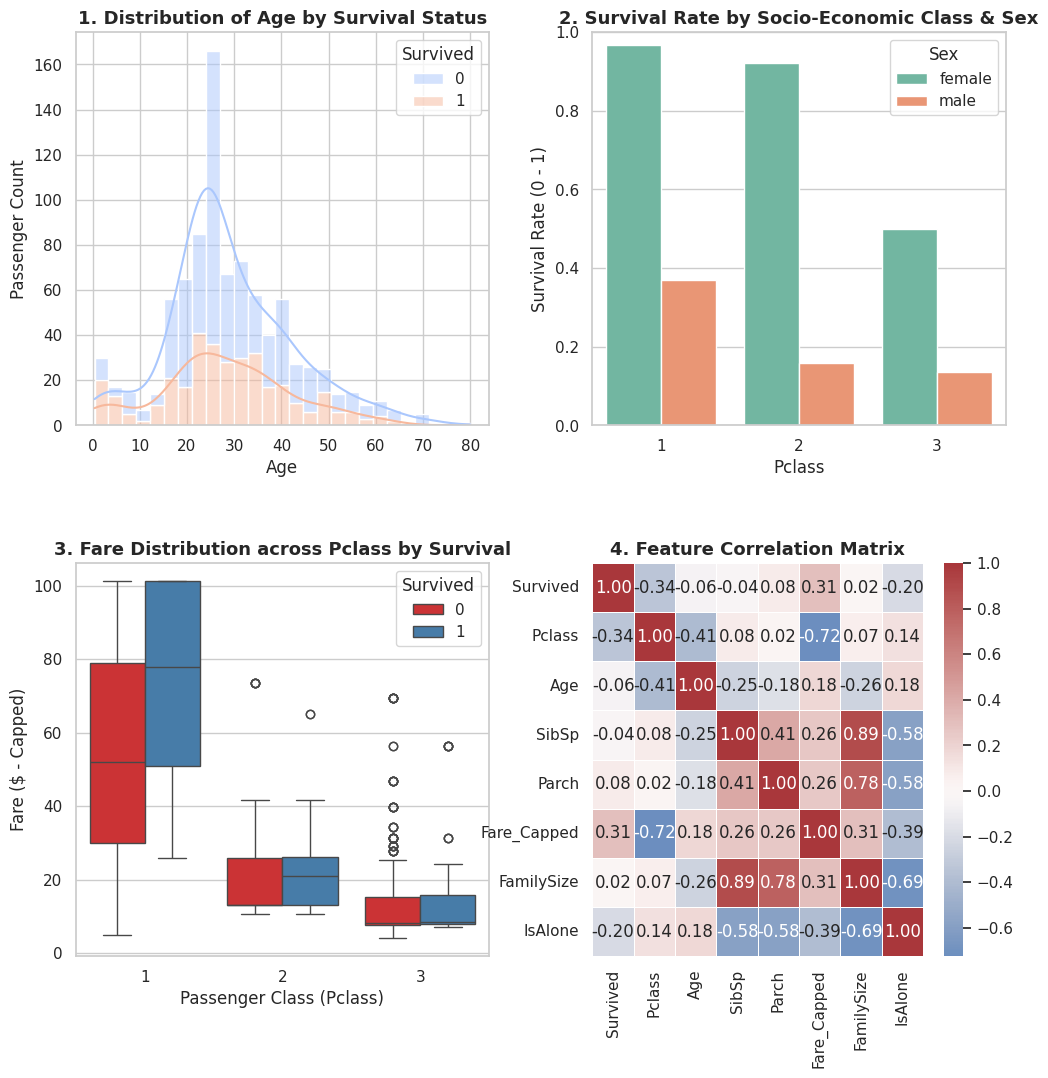

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# 1. Distribution: Age vs Survival (KDE Histogram)
sns.histplot(
    data=df,
    x="Age",
    hue="Survived",
    multiple="stack",
    kde=True,
    palette="coolwarm",
    ax=axes[0, 0],
)
axes[0, 0].set_title(
    "1. Distribution of Age by Survival Status",
    fontsize=13,
    fontweight="bold",
)
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Passenger Count")

# 2. Group Comparison: Survival Rate by Sex and Pclass (Bar/Point Plot)
sns.barplot(
    data=df,
    x="Pclass",
    y="Survived",
    hue="Sex",
    palette="Set2",
    ci=None,
    ax=axes[0, 1],
)
axes[0, 1].set_title(
    "2. Survival Rate by Socio-Economic Class & Sex",
    fontsize=13,
    fontweight="bold",
)
axes[0, 1].set_ylabel("Survival Rate (0 - 1)")
axes[0, 1].set_ylim(0, 1)

# 3. Outlier / Distribution Check: Fare by Passenger Class (Boxplot)
sns.boxplot(
    data=df,
    x="Pclass",
    y="Fare_Capped",
    hue="Survived",
    palette="Set1",
    ax=axes[1, 0],
)
axes[1, 0].set_title(
    "3. Fare Distribution across Pclass by Survival",
    fontsize=13,
    fontweight="bold",
)
axes[1, 0].set_xlabel("Passenger Class (Pclass)")
axes[1, 0].set_ylabel("Fare ($ - Capped)")

# 4. Correlation Matrix Heatmap
numeric_cols = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare_Capped",
    "FamilySize",
    "IsAlone",
]
corr_matrix = df[numeric_cols].corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=0.5,
    ax=axes[1, 1],
)
axes[1, 1].set_title(
    "4. Feature Correlation Matrix", fontsize=13, fontweight="bold"
)

plt.show()